In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded ✓")

Libraries loaded ✓


In [ ]:
customers  = pd.read_csv('customers.csv')
drivers    = pd.read_csv('drivers.csv')
vehicles   = pd.read_csv('vehicles.csv')
hubs       = pd.read_csv('hubs.csv')
orders     = pd.read_csv('orders.csv')
deliveries = pd.read_csv('deliveries.csv')
incidents  = pd.read_csv('incidents.csv')
complaints = pd.read_csv('complaints.csv')
app_events = pd.read_csv('app_events.csv')

print("All datasets loaded.")
for name, df in [('customers', customers), ('drivers', drivers),
                 ('vehicles', vehicles), ('hubs', hubs),
                 ('orders', orders), ('deliveries', deliveries),
                 ('incidents', incidents), ('complaints', complaints),
                 ('app_events', app_events)]:
    print(f"  {name}: {len(df):,} rows")

All datasets loaded.
  customers: 650 rows
  drivers: 170 rows
  vehicles: 120 rows
  hubs: 8 rows
  orders: 1,250 rows
  deliveries: 950 rows
  incidents: 280 rows
  complaints: 320 rows
  app_events: 640 rows


In [ ]:
ZONE_MAP = {
    'North': 'North', 'NORTH': 'North', 'north': 'North',
    'South': 'South', 'SOUTH': 'South',
    'East': 'East', 'EAST': 'East',
    'West': 'West', 'WEST': 'West',
    'Central': 'Central', 'CENTRAL': 'Central', 'Ctr': 'Central',
    'Airport': 'Airport', 'AIRPORT': 'Airport',
    'Riverside': 'Riverside', 'RiverSide': 'Riverside',
}

def fix_zones(df, *cols):
    df = df.copy()
    for col in cols:
        if col in df.columns:
            df[col] = df[col].map(ZONE_MAP).fillna(df[col])
    return df

customers  = fix_zones(customers,  'home_zone')
drivers    = fix_zones(drivers,    'base_zone')
vehicles   = fix_zones(vehicles,   'assigned_zone')
orders     = fix_zones(orders,     'pickup_zone', 'dropoff_zone')
app_events = fix_zones(app_events, 'zone_context')

print("Zone names cleaned ✓")
print("Unique zones:", sorted(customers['home_zone'].unique()))

Zone names cleaned ✓
Unique zones: ['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']


In [ ]:
# Fix datetime columns
orders['order_created_at']          = pd.to_datetime(orders['order_created_at'],          errors='coerce')
deliveries['dispatch_time']         = pd.to_datetime(deliveries['dispatch_time'],          errors='coerce')
deliveries['delivery_completed_at'] = pd.to_datetime(deliveries['delivery_completed_at'], errors='coerce')
complaints['created_at']            = pd.to_datetime(complaints['created_at'],             errors='coerce')
app_events['event_timestamp']       = pd.to_datetime(app_events['event_timestamp'],        errors='coerce')
customers['signup_date']            = pd.to_datetime(customers['signup_date'],             errors='coerce')

# Fill missing values
customers['loyalty_score']     = customers['loyalty_score'].fillna(customers['loyalty_score'].median())
customers['preferred_channel'] = customers['preferred_channel'].fillna('Unknown')
drivers['training_score']      = drivers['training_score'].fillna(drivers['training_score'].median())
vehicles['battery_health_pct'] = vehicles['battery_health_pct'].fillna(vehicles['battery_health_pct'].median())
orders['booking_channel']      = orders['booking_channel'].fillna('Unknown')
incidents['resolved_hours']    = incidents['resolved_hours'].fillna(incidents['resolved_hours'].median())
complaints['compensation_amount'] = complaints['compensation_amount'].fillna(0.0)

# Flag missing delivery completions — don't impute these
deliveries['completion_missing'] = deliveries['delivery_completed_at'].isnull().astype(int)

print("Missing values handled ✓")
print(f"Deliveries with no completion time: {deliveries['completion_missing'].sum()}")

Missing values handled ✓
Deliveries with no completion time: 19


In [ ]:
# Calculate delivery duration in hours
deliveries['delivery_duration_hrs'] = (
    (deliveries['delivery_completed_at'] - deliveries['dispatch_time'])
    .dt.total_seconds() / 3600
)

# Flag invalid timestamps (completed before dispatch)
deliveries['invalid_timestamp'] = (deliveries['delivery_duration_hrs'] < 0).astype(int)

# Flag delayed or failed deliveries
deliveries['is_delayed'] = deliveries['delivery_status'].isin(['Delayed', 'Failed']).astype(int)

# Flag deliveries with manual route overrides
deliveries['has_override'] = (deliveries['manual_route_override_count'] > 0).astype(int)

# Add order month and hour
orders['order_month'] = orders['order_created_at'].dt.to_period('M').astype(str)
orders['order_hour']  = orders['order_created_at'].dt.hour

# Customer tenure in days
customers['tenure_days'] = (pd.Timestamp('2026-01-01') - customers['signup_date']).dt.days

print("Feature engineering complete ✓")
print(f"Invalid timestamps found: {deliveries['invalid_timestamp'].sum()}")
print(f"Delayed or failed deliveries: {deliveries['is_delayed'].sum()} out of {len(deliveries)}")

Feature engineering complete ✓
Invalid timestamps found: 64
Delayed or failed deliveries: 334 out of 950


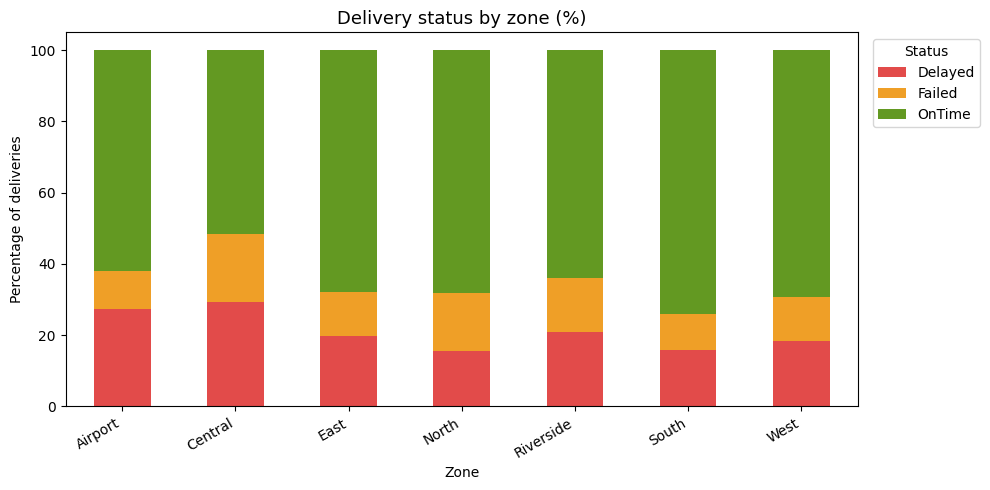

delivery_status  Delayed  Failed  OnTime
pickup_zone                             
Airport             27.4    10.6    61.9
Central             29.3    19.0    51.7
East                19.9    12.2    67.9
North               15.6    16.3    68.1
Riverside           21.0    15.1    63.9
South               15.8    10.1    74.1
West                18.4    12.3    69.3


In [ ]:
# Join deliveries with orders to get zone info
del_orders = deliveries.merge(
    orders[['order_id', 'pickup_zone', 'service_type']],
    on='order_id', how='left'
)

# Calculate delivery status by zone
zone_status = del_orders.groupby(['pickup_zone', 'delivery_status']).size().unstack(fill_value=0)
zone_status_pct = zone_status.div(zone_status.sum(axis=1), axis=0) * 100

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
zone_status_pct.plot(kind='bar', stacked=True, ax=ax,
                     color=['#E24B4A', '#EF9F27', '#639922'])
ax.set_title('Delivery status by zone (%)', fontsize=13)
ax.set_xlabel('Zone')
ax.set_ylabel('Percentage of deliveries')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(title='Status', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

print(zone_status_pct.round(1).to_string())

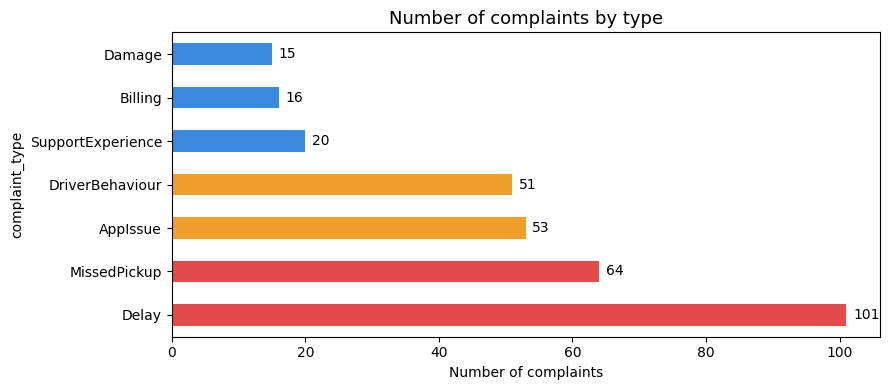

complaint_type
Delay                101
MissedPickup          64
AppIssue              53
DriverBehaviour       51
SupportExperience     20
Billing               16
Damage                15


In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
complaint_counts = complaints['complaint_type'].value_counts()
colors = ['#E24B4A' if i < 2 else '#EF9F27' if i < 4 else '#378ADD'
          for i in range(len(complaint_counts))]
complaint_counts.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Number of complaints by type', fontsize=13)
ax.set_xlabel('Number of complaints')
for i, v in enumerate(complaint_counts):
    ax.text(v + 1, i, str(v), va='center', fontsize=10)
plt.tight_layout()
plt.show()

print(complaint_counts.to_string())

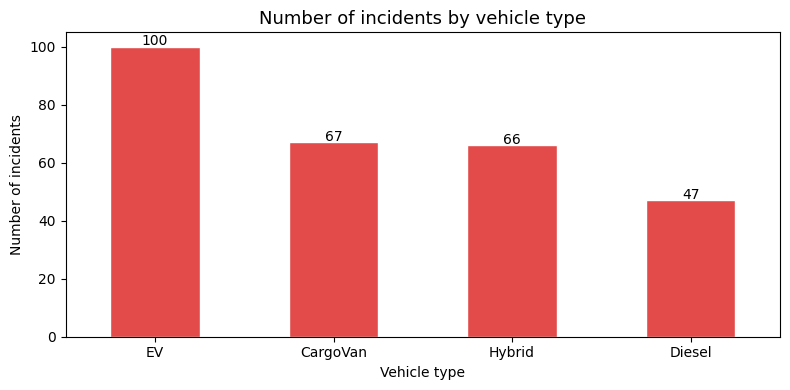

vehicle_type
EV          100
CargoVan     67
Hybrid       66
Diesel       47


In [ ]:
# Join incidents to deliveries to get vehicle info
inc_del = incidents.merge(
    deliveries[['delivery_id', 'vehicle_id', 'driver_id']],
    on='delivery_id', how='left'
).merge(
    vehicles[['vehicle_id', 'vehicle_type', 'maintenance_status']],
    on='vehicle_id', how='left'
)

incident_by_vehicle = inc_del.groupby('vehicle_type')['incident_id'].count().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
incident_by_vehicle.plot(kind='bar', ax=ax, color='#E24B4A', edgecolor='white')
ax.set_title('Number of incidents by vehicle type', fontsize=13)
ax.set_xlabel('Vehicle type')
ax.set_ylabel('Number of incidents')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for i, v in enumerate(incident_by_vehicle):
    ax.text(i, v + 0.5, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

print(incident_by_vehicle.to_string())

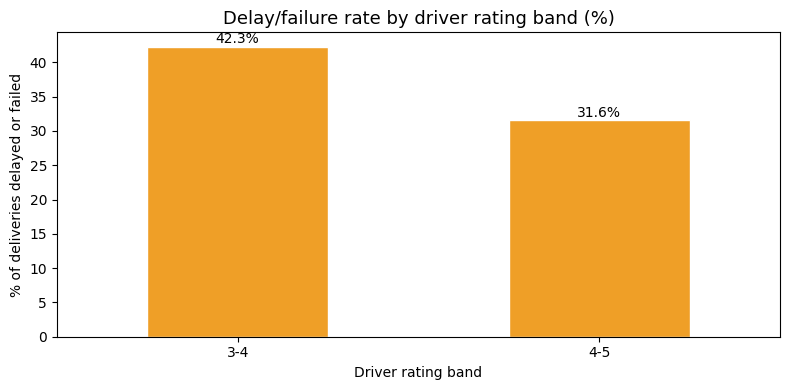

rating_band
3-4    42.3
4-5    31.6


In [ ]:
# Join deliveries with drivers
del_drivers = deliveries.merge(
    drivers[['driver_id', 'driver_rating', 'years_experience', 'employment_type']],
    on='driver_id', how='left'
)

# Average failure rate by driver rating band
del_drivers['rating_band'] = pd.cut(del_drivers['driver_rating'],
                                     bins=[0, 2, 3, 4, 5],
                                     labels=['0-2', '2-3', '3-4', '4-5'])

failure_by_rating = del_drivers.groupby('rating_band', observed=True)['is_delayed'].mean() * 100

fig, ax = plt.subplots(figsize=(8, 4))
failure_by_rating.plot(kind='bar', ax=ax, color='#EF9F27', edgecolor='white')
ax.set_title('Delay/failure rate by driver rating band (%)', fontsize=13)
ax.set_xlabel('Driver rating band')
ax.set_ylabel('% of deliveries delayed or failed')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for i, v in enumerate(failure_by_rating):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

print(failure_by_rating.round(1).to_string())